## Machine Learning on Synthetic Data Adjustment

🚀 Cybersecurity Synthetic Data Evaluation Framework
📊 Configuration:
  • Real-world malicious ratio: 10.0%
  • Synthetic strategies: ['balanced_augmentation', 'malicious_only_augmentation']
  • Synthetic ratios to test: ['0%', '10%', '20%', '30%', '40%', '50%']
  • Random state: 42
📊 Loading and exploring mixed dataset...
Dataset shape: (200, 5)
Columns: ['body', 'label', 'source', 'subject', 'synthetic']

📈 Dataset Overview:
Total samples: 200
Features: 4

🎯 Target Distribution (label):
label
1    103
0     97
Name: count, dtype: int64
Malicious ratio: 51.50%

🔬 Data Source Distribution:
Real samples: 100
Synthetic samples: 100
Synthetic ratio: 50.00%

📊 Synthetic vs Label Cross-tabulation:
label       0    1  All
synthetic              
0          48   52  100
1          49   51  100
All        97  103  200

🔍 Class Distribution Analysis:
Real data malicious ratio: 52.00%
Synthetic data malicious ratio: 51.00%

📝 Text Feature Analysis - subject:
Average length: 42.5 characters
Max le

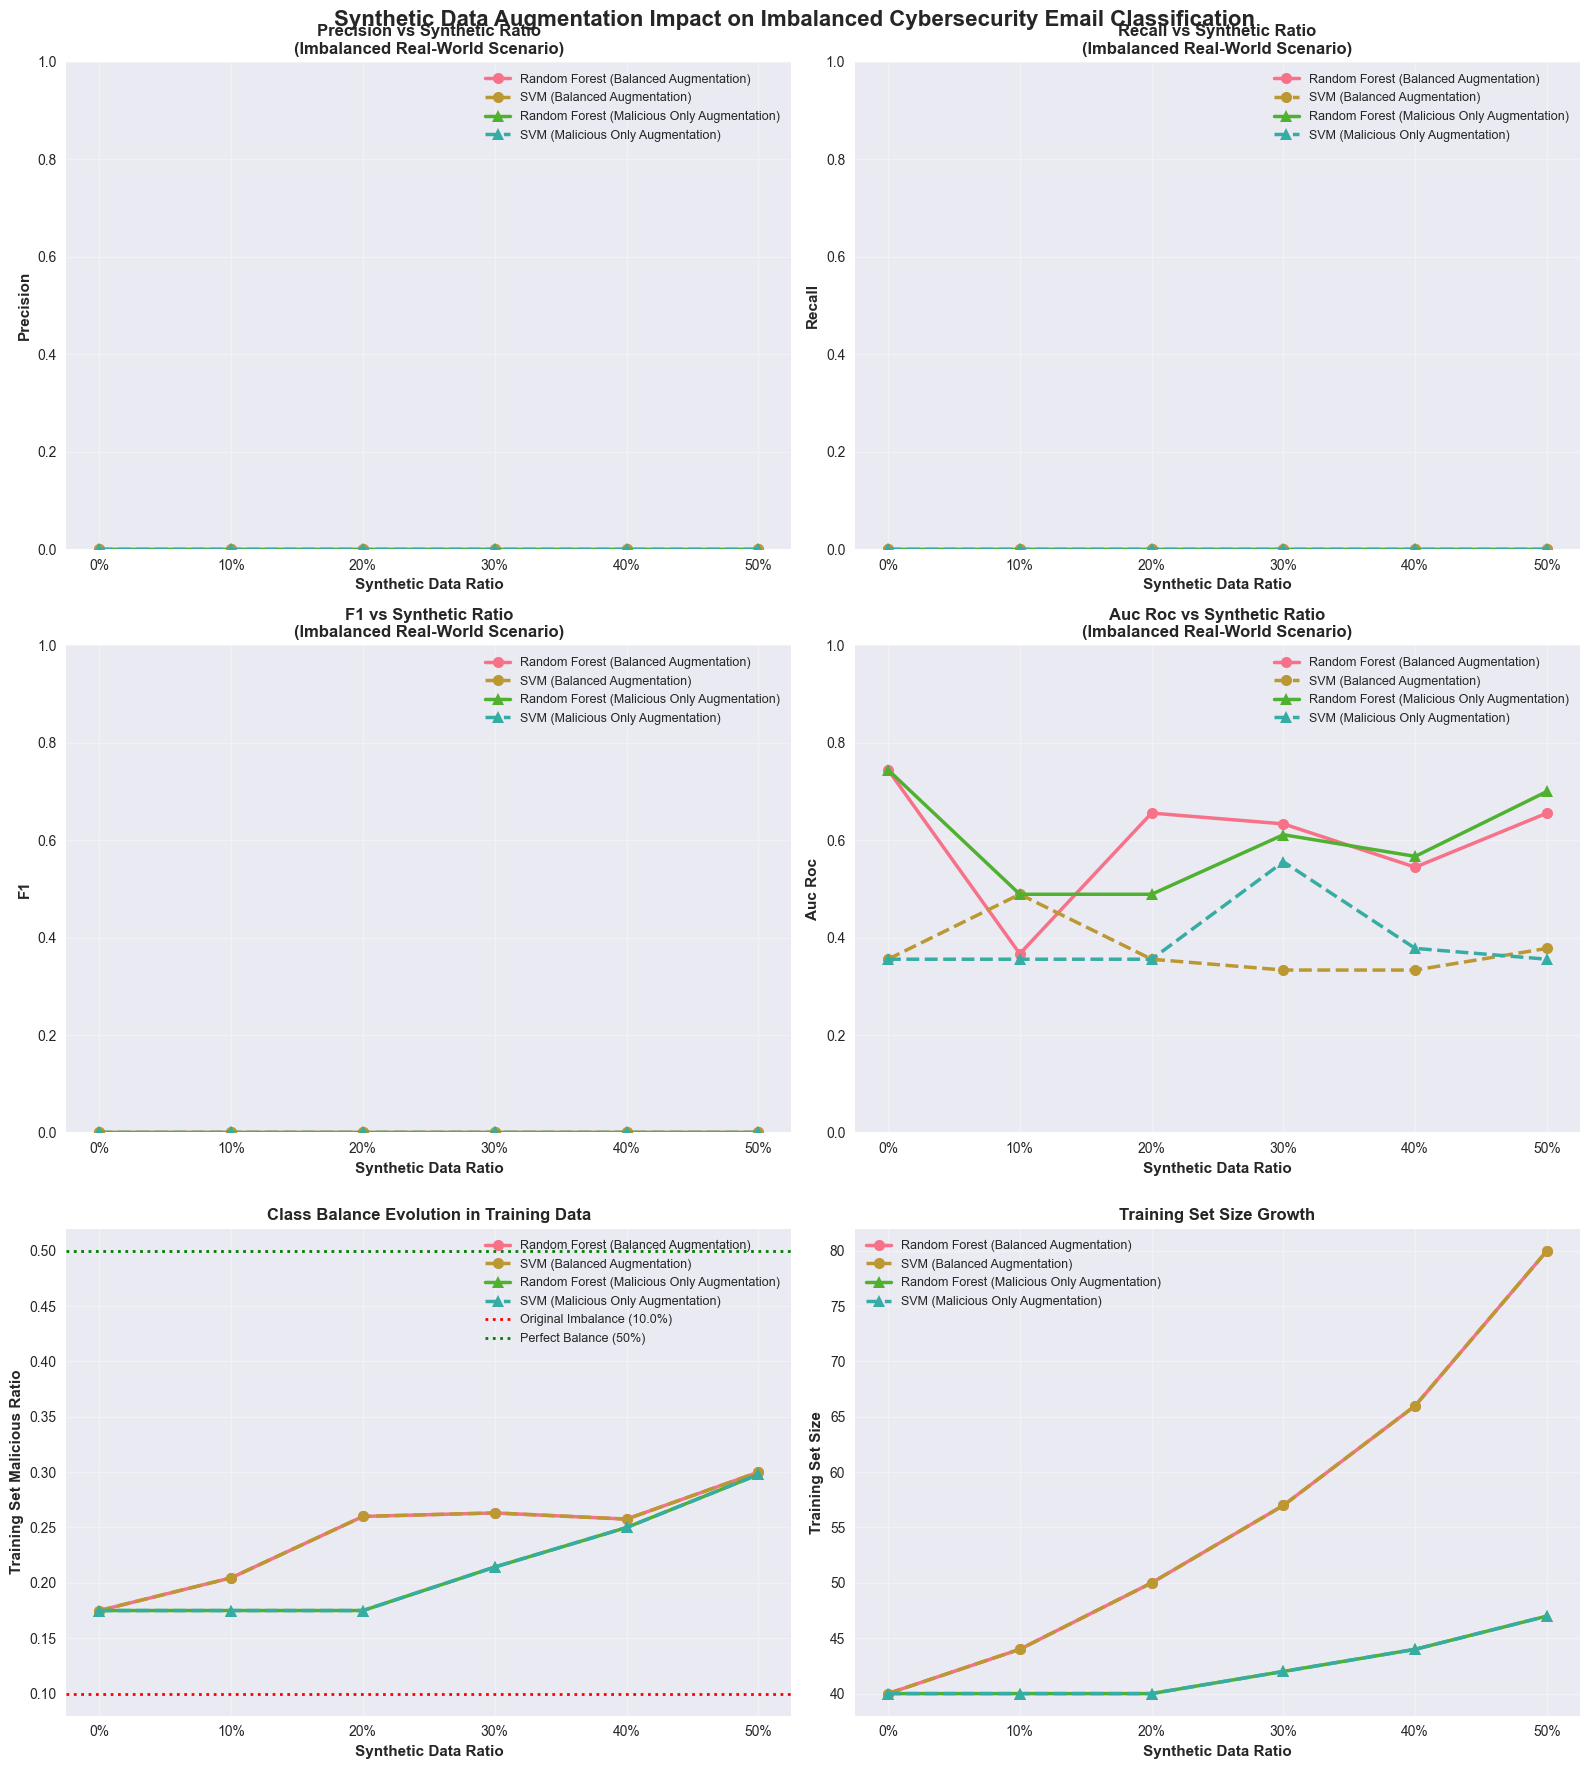


🔍 STRATEGY COMPARISON AND INSIGHTS

1️⃣ AUGMENTATION STRATEGY EFFECTIVENESS:

Random Forest:
  At 20% synthetic ratio:
    Balanced Aug:     F1=0.000, P=0.000, R=0.000
    Malicious-Only:   F1=0.000, P=0.000, R=0.000
    → Malicious-only advantage: +0.000 F1
  At 40% synthetic ratio:
    Balanced Aug:     F1=0.000, P=0.000, R=0.000
    Malicious-Only:   F1=0.000, P=0.000, R=0.000
    → Malicious-only advantage: +0.000 F1

SVM:
  At 20% synthetic ratio:
    Balanced Aug:     F1=0.000, P=0.000, R=0.000
    Malicious-Only:   F1=0.000, P=0.000, R=0.000
    → Malicious-only advantage: +0.000 F1
  At 40% synthetic ratio:
    Balanced Aug:     F1=0.000, P=0.000, R=0.000
    Malicious-Only:   F1=0.000, P=0.000, R=0.000
    → Malicious-only advantage: +0.000 F1

2️⃣ CLASS IMBALANCE HANDLING:

Random Forest (Baseline: Recall=0.000, Precision=0.000):
  Balanced Augmentation:
    Best recall: 0.000 at 0% (++0.000)
    Precision impact: +0.000
  Malicious Only Augmentation:
    Best recall: 0.000 

In [2]:
# ================================================================================
# 7. ENHANCED CONFUSION MATRIX ANALYSIS
# ================================================================================

def analyze_confusion_matrices_strategies(experiment, synthetic_ratios=[0, 0.2, 0.5]):
    """Analyze confusion matrices for different strategies and ratios."""
    print(f"\n🎯 CONFUSION MATRIX ANALYSIS - STRATEGY COMPARISON")
    print("="*70)
    
    models = {
        'Random Forest': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'SVM': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
            ('scaler', StandardScaler(with_mean=False)),
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ])
    }
    
    strategies = ['balanced_augmentation', 'malicious_only_augmentation']
    
    fig, axes = plt.subplots(len(models) * len(strategies), len(synthetic_ratios), 
                           figsize=(5*len(synthetic_ratios), 4*len(models)*len(strategies)))
    
    # Ensure axes is 2D
    if len(models) * len(strategies) == 1:
        axes = axes.reshape(1, -1)
    elif len(synthetic_ratios) == 1:
        axes = axes.reshape(-1, 1)
    
    for model_idx, (model_name, model) in enumerate(models.items()):
        for strategy_idx, strategy in enumerate(strategies):
            row_idx = model_idx * len(strategies) + strategy_idx
            
            for ratio_idx, ratio in enumerate(synthetic_ratios):
                # Create training set based on strategy
                if strategy == 'balanced_augmentation':
                    X_train, y_train = experiment.create_training_set_balanced_augmentation(ratio)
                else:
                    X_train, y_train = experiment.create_training_set_malicious_only_augmentation(ratio)
                
                # Train model
                model.fit(X_train, y_train)
                
                # Predict and create confusion matrix
                y_pred = model.predict(experiment.X_test)
                cm = confusion_matrix(experiment.y_test, y_pred)
                
                # Plot confusion matrix
                ax = axes[row_idx, ratio_idx]
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                           xticklabels=['Benign', 'Malicious'],
                           yticklabels=['Benign', 'Malicious'])
                
                strategy_label = strategy.replace('_', ' ').title()
                ax.set_title(f'{model_name} - {strategy_label}\nSynthetic Ratio: {ratio:.0%}')
                ax.set_xlabel('Predicted')
                ax.set_ylabel('Actual')
                
                # Calculate and display metrics
                tn, fp, fn, tp = cm.ravel()
                precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0 # Synthetic Data Ratio Evaluation for Cybersecurity Email Classification
# Research Question: How does synthetic data ratio (0%-50%) impact model performance on real-world threat detection?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ================================================================================
# CONFIGURATION PARAMETERS
# ================================================================================

# Real-world imbalance configuration (typical for email phishing datasets)
REAL_WORLD_MALICIOUS_RATIO = 0.1  # 10% malicious, 90% benign (realistic imbalance)
# Common ratios in literature: 0.05 (5%), 0.1 (10%), 0.15 (15%), 0.2 (20%)

# Synthetic data augmentation strategies
SYNTHETIC_STRATEGIES = [
    'balanced_augmentation',  # Add both malicious and benign synthetic data proportionally
    'malicious_only_augmentation'  # Add only synthetic malicious data to balance classes
]

# Synthetic ratios to test
SYNTHETIC_RATIOS = [0, 0.1, 0.2, 0.3, 0.4, 0.5]

# Random state for reproducibility
RANDOM_STATE = 42

print("🚀 Cybersecurity Synthetic Data Evaluation Framework")
print("="*60)
print(f"📊 Configuration:")
print(f"  • Real-world malicious ratio: {REAL_WORLD_MALICIOUS_RATIO:.1%}")
print(f"  • Synthetic strategies: {SYNTHETIC_STRATEGIES}")
print(f"  • Synthetic ratios to test: {[f'{r:.0%}' for r in SYNTHETIC_RATIOS]}")
print(f"  • Random state: {RANDOM_STATE}")

# ================================================================================
# 1. DATA LOADING AND EXPLORATION
# ================================================================================

def load_and_explore_data(file_path):
    """Load mixed dataset and perform initial exploration."""
    print("📊 Loading and exploring mixed dataset...")
    
    # Load data
    df = pd.read_csv(file_path)
    
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print("\n" + "="*50)
    
    # Basic statistics
    print("📈 Dataset Overview:")
    print(f"Total samples: {len(df)}")
    print(f"Features: {len(df.columns) - 1}")  # Excluding target
    
    # Target distribution
    print(f"\n🎯 Target Distribution (label):")
    label_dist = df['label'].value_counts()
    print(label_dist)
    print(f"Malicious ratio: {label_dist.get(1, 0) / len(df):.2%}")
    
    # Synthetic vs Real distribution
    if 'synthetic' in df.columns:
        print(f"\n🔬 Data Source Distribution:")
        synthetic_dist = df['synthetic'].value_counts()
        print(f"Real samples: {synthetic_dist.get(0, 0)}")
        print(f"Synthetic samples: {synthetic_dist.get(1, 0)}")
        print(f"Synthetic ratio: {synthetic_dist.get(1, 0) / len(df):.2%}")
        
        # Cross-tabulation of synthetic and label
        print(f"\n📊 Synthetic vs Label Cross-tabulation:")
        crosstab = pd.crosstab(df['synthetic'], df['label'], margins=True)
        print(crosstab)
        
        # Analyze class distribution by data source
        print(f"\n🔍 Class Distribution Analysis:")
        real_data = df[df['synthetic'] == 0]
        synthetic_data = df[df['synthetic'] == 1]
        
        if len(real_data) > 0:
            real_malicious_ratio = real_data['label'].sum() / len(real_data)
            print(f"Real data malicious ratio: {real_malicious_ratio:.2%}")
        
        if len(synthetic_data) > 0:
            synthetic_malicious_ratio = synthetic_data['label'].sum() / len(synthetic_data)
            print(f"Synthetic data malicious ratio: {synthetic_malicious_ratio:.2%}")
    
    # Text feature analysis
    text_columns = ['subject', 'body']
    for col in text_columns:
        if col in df.columns:
            print(f"\n📝 Text Feature Analysis - {col}:")
            print(f"Average length: {df[col].str.len().mean():.1f} characters")
            print(f"Max length: {df[col].str.len().max()}")
            print(f"Min length: {df[col].str.len().min()}")
            print(f"Missing values: {df[col].isnull().sum()}")
    
    return df

# Load data
data_path = "../data/mixed/mixed_five_email_phishing_Phishing_and_Spam_Email_Campaigns_100+100.csv"
df = load_and_explore_data(data_path)

# ================================================================================
# 2. DATA PREPARATION AND PREPROCESSING
# ================================================================================

def prepare_features_and_target(df):
    """Prepare text features and target variable."""
    print("\n🔧 Preparing features and target...")
    
    # Combine text features
    text_features = []
    if 'subject' in df.columns:
        text_features.append('subject')
    if 'body' in df.columns:
        text_features.append('body')
    
    # Handle missing values
    for col in text_features:
        df[col] = df[col].fillna('')
    
    # Combine text columns
    if len(text_features) > 1:
        df['combined_text'] = df[text_features].apply(
            lambda x: ' '.join(x.astype(str)), axis=1
        )
        text_column = 'combined_text'
    else:
        text_column = text_features[0]
    
    print(f"Using text column: {text_column}")
    print(f"Sample text: {df[text_column].iloc[0][:100]}...")
    
    # Prepare features and target
    X = df[text_column]
    y = df['label']
    synthetic_flag = df.get('synthetic', pd.Series([0] * len(df)))  # Default to real if no synthetic column
    
    return X, y, synthetic_flag

X, y, synthetic_flag = prepare_features_and_target(df)

# ================================================================================
# 3. IMBALANCED DATA HANDLING AND SYNTHETIC AUGMENTATION STRATEGIES
# ================================================================================

def create_realistic_imbalanced_dataset(X, y, synthetic_flag, target_malicious_ratio=REAL_WORLD_MALICIOUS_RATIO):
    """Create a realistic imbalanced dataset from the mixed data."""
    print(f"\n🎯 Creating realistic imbalanced dataset with {target_malicious_ratio:.1%} malicious ratio...")
    
    # Separate real and synthetic data
    real_indices = synthetic_flag[synthetic_flag == 0].index
    synthetic_indices = synthetic_flag[synthetic_flag == 1].index
    
    # Get real data
    real_X = X.loc[real_indices]
    real_y = y.loc[real_indices]
    
    # Get synthetic data
    synthetic_X = X.loc[synthetic_indices] if len(synthetic_indices) > 0 else pd.Series(dtype=object)
    synthetic_y = y.loc[synthetic_indices] if len(synthetic_indices) > 0 else pd.Series(dtype=int)
    
    # Create imbalanced real dataset
    real_malicious = real_X[real_y == 1]
    real_benign = real_X[real_y == 0]
    real_malicious_y = real_y[real_y == 1]
    real_benign_y = real_y[real_y == 0]
    
    print(f"Available real data: {len(real_malicious)} malicious, {len(real_benign)} benign")
    
    # Calculate target counts for realistic imbalance
    total_real_target = min(len(real_malicious) + len(real_benign), 1000)  # Limit total size
    target_malicious_count = int(total_real_target * target_malicious_ratio)
    target_benign_count = total_real_target - target_malicious_count
    
    # Sample to create imbalanced dataset
    if len(real_malicious) >= target_malicious_count:
        sampled_malicious_X = real_malicious.sample(n=target_malicious_count, random_state=RANDOM_STATE)
        sampled_malicious_y = real_malicious_y.loc[sampled_malicious_X.index]
    else:
        sampled_malicious_X = real_malicious
        sampled_malicious_y = real_malicious_y
        target_malicious_count = len(real_malicious)
        target_benign_count = int(target_malicious_count / target_malicious_ratio - target_malicious_count)
    
    if len(real_benign) >= target_benign_count:
        sampled_benign_X = real_benign.sample(n=target_benign_count, random_state=RANDOM_STATE)
        sampled_benign_y = real_benign_y.loc[sampled_benign_X.index]
    else:
        sampled_benign_X = real_benign
        sampled_benign_y = real_benign_y
    
    # Combine imbalanced real dataset
    imbalanced_X = pd.concat([sampled_malicious_X, sampled_benign_X], ignore_index=True)
    imbalanced_y = pd.concat([sampled_malicious_y, sampled_benign_y], ignore_index=True)
    
    # Shuffle
    indices = np.random.RandomState(RANDOM_STATE).permutation(len(imbalanced_X))
    imbalanced_X = imbalanced_X.iloc[indices].reset_index(drop=True)
    imbalanced_y = imbalanced_y.iloc[indices].reset_index(drop=True)
    
    actual_malicious_ratio = imbalanced_y.sum() / len(imbalanced_y)
    print(f"Created imbalanced dataset: {len(imbalanced_X)} samples")
    print(f"Actual malicious ratio: {actual_malicious_ratio:.2%} ({imbalanced_y.sum()} malicious, {len(imbalanced_y) - imbalanced_y.sum()} benign)")
    
    return imbalanced_X, imbalanced_y, synthetic_X, synthetic_y


class ImbalancedSyntheticExperiment:
    """Enhanced experiment framework for imbalanced data with synthetic augmentation strategies."""
    
    def __init__(self, X, y, synthetic_flag, test_size=0.3, random_state=RANDOM_STATE):
        self.random_state = random_state
        self.test_size = test_size
        self.results = {}
        
        # Create realistic imbalanced dataset
        self.X_imbalanced, self.y_imbalanced, self.X_synthetic, self.y_synthetic = \
            create_realistic_imbalanced_dataset(X, y, synthetic_flag)
        
        # Split imbalanced data into train and test (test set is always 100% real)
        self._create_real_test_set()
        
    def _create_real_test_set(self):
        """Create a test set with only real imbalanced data."""
        print(f"\n🎯 Creating real-world imbalanced test set...")
        
        self.X_real_train, self.X_test, self.y_real_train, self.y_test = train_test_split(
            self.X_imbalanced, self.y_imbalanced, 
            test_size=self.test_size, 
            random_state=self.random_state,
            stratify=self.y_imbalanced
        )
        
        print(f"Real training pool: {len(self.X_real_train)} samples")
        print(f"  - Malicious: {self.y_real_train.sum()} ({self.y_real_train.sum()/len(self.y_real_train):.1%})")
        print(f"  - Benign: {len(self.y_real_train) - self.y_real_train.sum()}")
        
        print(f"Test set (100% real): {len(self.X_test)} samples")
        print(f"  - Malicious: {self.y_test.sum()} ({self.y_test.sum()/len(self.y_test):.1%})")
        print(f"  - Benign: {len(self.y_test) - self.y_test.sum()}")
        
        print(f"Synthetic pool: {len(self.X_synthetic)} samples")
        if len(self.X_synthetic) > 0:
            print(f"  - Malicious: {self.y_synthetic.sum()} ({self.y_synthetic.sum()/len(self.y_synthetic):.1%})")
            print(f"  - Benign: {len(self.y_synthetic) - self.y_synthetic.sum()}")
        
    def create_training_set_balanced_augmentation(self, synthetic_ratio):
        """Create training set with balanced synthetic augmentation (both malicious and benign)."""
        if synthetic_ratio == 0:
            return self.X_real_train, self.y_real_train
        
        # Calculate how many synthetic samples to add proportionally
        n_real = len(self.X_real_train)
        n_synthetic_needed = int((synthetic_ratio / (1 - synthetic_ratio)) * n_real)
        
        if len(self.X_synthetic) == 0:
            print(f"⚠️  No synthetic data available!")
            return self.X_real_train, self.y_real_train
        
        # Sample synthetic data maintaining its original distribution
        if n_synthetic_needed <= len(self.X_synthetic):
            synthetic_sample = self.X_synthetic.sample(n=n_synthetic_needed, random_state=self.random_state)
            synthetic_y_sample = self.y_synthetic.loc[synthetic_sample.index]
        else:
            print(f"⚠️  Need {n_synthetic_needed} synthetic samples but only {len(self.X_synthetic)} available.")
            synthetic_sample = self.X_synthetic
            synthetic_y_sample = self.y_synthetic
            n_synthetic_needed = len(self.X_synthetic)
        
        # Combine real and synthetic data
        X_train = pd.concat([self.X_real_train, synthetic_sample], ignore_index=True)
        y_train = pd.concat([self.y_real_train, synthetic_y_sample], ignore_index=True)
        
        # Shuffle
        indices = np.random.RandomState(self.random_state).permutation(len(X_train))
        X_train = X_train.iloc[indices].reset_index(drop=True)
        y_train = y_train.iloc[indices].reset_index(drop=True)
        
        actual_ratio = n_synthetic_needed / len(X_train)
        malicious_ratio = y_train.sum() / len(y_train)
        
        print(f"Balanced augmentation: {len(X_train)} samples ({actual_ratio:.1%} synthetic)")
        print(f"  - Final malicious ratio: {malicious_ratio:.2%}")
        
        return X_train, y_train
    
    def create_training_set_malicious_only_augmentation(self, synthetic_ratio):
        """Create training set with malicious-only synthetic augmentation to balance classes."""
        if synthetic_ratio == 0:
            return self.X_real_train, self.y_real_train
        
        if len(self.X_synthetic) == 0:
            print(f"⚠️  No synthetic data available!")
            return self.X_real_train, self.y_real_train
        
        # Get synthetic malicious samples only
        synthetic_malicious_mask = self.y_synthetic == 1
        synthetic_malicious_X = self.X_synthetic[synthetic_malicious_mask]
        synthetic_malicious_y = self.y_synthetic[synthetic_malicious_mask]
        
        if len(synthetic_malicious_X) == 0:
            print(f"⚠️  No synthetic malicious samples available!")
            return self.X_real_train, self.y_real_train
        
        # Calculate how many synthetic malicious samples to add
        n_real_malicious = self.y_real_train.sum()
        n_real_benign = len(self.y_real_train) - n_real_malicious
        
        # Target: move from current imbalance towards balance based on synthetic_ratio
        # synthetic_ratio = 0.5 means fully balanced (50% malicious)
        # synthetic_ratio = 0.0 means keep original imbalance
        target_malicious_ratio = REAL_WORLD_MALICIOUS_RATIO + synthetic_ratio * (0.5 - REAL_WORLD_MALICIOUS_RATIO)
        
        # Calculate needed malicious samples to reach target ratio
        target_total = n_real_benign / (1 - target_malicious_ratio)
        target_malicious = target_total * target_malicious_ratio
        n_synthetic_malicious_needed = max(0, int(target_malicious - n_real_malicious))
        
        # Sample synthetic malicious data
        if n_synthetic_malicious_needed > 0:
            if n_synthetic_malicious_needed <= len(synthetic_malicious_X):
                synthetic_sample = synthetic_malicious_X.sample(n=n_synthetic_malicious_needed, random_state=self.random_state)
                synthetic_y_sample = synthetic_malicious_y.loc[synthetic_sample.index]
            else:
                print(f"⚠️  Need {n_synthetic_malicious_needed} synthetic malicious samples but only {len(synthetic_malicious_X)} available.")
                synthetic_sample = synthetic_malicious_X
                synthetic_y_sample = synthetic_malicious_y
                n_synthetic_malicious_needed = len(synthetic_malicious_X)
            
            # Combine real and synthetic data
            X_train = pd.concat([self.X_real_train, synthetic_sample], ignore_index=True)
            y_train = pd.concat([self.y_real_train, synthetic_y_sample], ignore_index=True)
        else:
            X_train = self.X_real_train
            y_train = self.y_real_train
            n_synthetic_malicious_needed = 0
        
        # Shuffle
        indices = np.random.RandomState(self.random_state).permutation(len(X_train))
        X_train = X_train.iloc[indices].reset_index(drop=True)
        y_train = y_train.iloc[indices].reset_index(drop=True)
        
        actual_synthetic_ratio = n_synthetic_malicious_needed / len(X_train) if len(X_train) > 0 else 0
        malicious_ratio = y_train.sum() / len(y_train)
        
        print(f"Malicious-only augmentation: {len(X_train)} samples ({actual_synthetic_ratio:.1%} synthetic)")
        print(f"  - Added {n_synthetic_malicious_needed} synthetic malicious samples")
        print(f"  - Final malicious ratio: {malicious_ratio:.2%} (target: {target_malicious_ratio:.2%})")
        
        return X_train, y_train

    def evaluate_models(self, synthetic_ratios=SYNTHETIC_RATIOS, strategies=SYNTHETIC_STRATEGIES):
        """Evaluate models across different synthetic ratios and augmentation strategies."""
        print(f"\n🧪 Starting evaluation across synthetic ratios and strategies...")
        print(f"Ratios: {[f'{r:.0%}' for r in synthetic_ratios]}")
        print(f"Strategies: {strategies}")
        
        # Define models
        models = {
            'Random Forest': Pipeline([
                ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
                ('classifier', RandomForestClassifier(n_estimators=100, random_state=self.random_state, class_weight='balanced'))
            ]),
            'SVM': Pipeline([
                ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
                ('scaler', StandardScaler(with_mean=False)),
                ('classifier', SVC(random_state=self.random_state, probability=True, class_weight='balanced'))
            ])
        }
        
        results = {}
        
        for strategy in strategies:
            print(f"\n🔄 Evaluating strategy: {strategy}")
            results[strategy] = {}
            
            for ratio in synthetic_ratios:
                print(f"\n📊 Synthetic ratio: {ratio:.0%}")
                results[strategy][ratio] = {}
                
                # Create training set based on strategy
                if strategy == 'balanced_augmentation':
                    X_train, y_train = self.create_training_set_balanced_augmentation(ratio)
                elif strategy == 'malicious_only_augmentation':
                    X_train, y_train = self.create_training_set_malicious_only_augmentation(ratio)
                else:
                    raise ValueError(f"Unknown strategy: {strategy}")
                
                for model_name, model in models.items():
                    print(f"  🔄 Training {model_name}...")
                    
                    # Train model
                    model.fit(X_train, y_train)
                    
                    # Predict on test set (always real imbalanced data)
                    y_pred = model.predict(self.X_test)
                    y_pred_proba = model.predict_proba(self.X_test)[:, 1]
                    
                    # Calculate metrics
                    metrics = {
                        'accuracy': accuracy_score(self.y_test, y_pred),
                        'precision': precision_score(self.y_test, y_pred, zero_division=0),
                        'recall': recall_score(self.y_test, y_pred, zero_division=0),
                        'f1': f1_score(self.y_test, y_pred, zero_division=0),
                        'auc_roc': roc_auc_score(self.y_test, y_pred_proba),
                        'training_size': len(X_train),
                        'training_malicious_ratio': y_train.sum() / len(y_train),
                        'synthetic_samples': len(X_train) - len(self.X_real_train)
                    }
                    
                    # Cross-validation on training set
                    cv_scores = cross_val_score(
                        model, X_train, y_train, 
                        cv=3, scoring='f1', 
                        n_jobs=-1
                    )
                    metrics['cv_f1_mean'] = cv_scores.mean()
                    metrics['cv_f1_std'] = cv_scores.std()
                    
                    results[strategy][ratio][model_name] = metrics
                    
                    print(f"    ✅ {model_name} - F1: {metrics['f1']:.3f}, "
                          f"AUC: {metrics['auc_roc']:.3f}, "
                          f"Precision: {metrics['precision']:.3f}, "
                          f"Recall: {metrics['recall']:.3f}")
                    print(f"       Training malicious ratio: {metrics['training_malicious_ratio']:.2%}")
        
        self.results = results
        return results # ================================================================================
# 4. RUN EXPERIMENTS
# ================================================================================

# Initialize experiment
print("\n🚀 Initializing Imbalanced Synthetic Experiment...")
experiment = ImbalancedSyntheticExperiment(X, y, synthetic_flag, test_size=0.3, random_state=RANDOM_STATE)

# Run evaluation across different synthetic ratios and strategies
results = experiment.evaluate_models(SYNTHETIC_RATIOS, SYNTHETIC_STRATEGIES)

# ================================================================================
# 5. ENHANCED RESULTS ANALYSIS AND VISUALIZATION
# ================================================================================

def analyze_and_visualize_imbalanced_results(results):
    """Analyze and visualize experimental results for imbalanced data scenarios."""
    print("\n📊 Analyzing and visualizing imbalanced data results...")
    
    # Convert results to DataFrame for easier analysis
    rows = []
    for strategy, strategy_results in results.items():
        for ratio, ratio_results in strategy_results.items():
            for model_name, metrics in ratio_results.items():
                row = {
                    'strategy': strategy, 
                    'synthetic_ratio': ratio, 
                    'model': model_name
                }
                row.update(metrics)
                rows.append(row)
    
    results_df = pd.DataFrame(rows)
    
    # Summary statistics
    print("\n📈 Results Summary by Strategy:")
    summary = results_df.groupby(['strategy', 'model'])[['accuracy', 'precision', 'recall', 'f1', 'auc_roc']].agg(['mean', 'std']).round(3)
    print(summary)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('Synthetic Data Augmentation Impact on Imbalanced Cybersecurity Email Classification', 
                 fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['precision', 'recall', 'f1', 'auc_roc']
    
    # Plot main metrics
    for i, metric in enumerate(metrics_to_plot):
        ax = axes[i//2, i%2]
        
        for strategy in results_df['strategy'].unique():
            for model in results_df['model'].unique():
                data = results_df[(results_df['strategy'] == strategy) & (results_df['model'] == model)]
                label = f"{model} ({strategy.replace('_', ' ').title()})"
                marker = 'o' if strategy == 'balanced_augmentation' else '^'
                linestyle = '-' if model == 'Random Forest' else '--'
                
                ax.plot(data['synthetic_ratio'], data[metric], 
                       marker=marker, linewidth=2.5, markersize=8, 
                       label=label, linestyle=linestyle)
        
        ax.set_xlabel('Synthetic Data Ratio', fontweight='bold')
        ax.set_ylabel(metric.replace('_', ' ').title(), fontweight='bold')
        ax.set_title(f'{metric.replace("_", " ").title()} vs Synthetic Ratio\n(Imbalanced Real-World Scenario)', fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        ax.set_xticks(SYNTHETIC_RATIOS)
        ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS])
    
    # Training class balance evolution
    ax = axes[2, 0]
    for strategy in results_df['strategy'].unique():
        for model in results_df['model'].unique():
            data = results_df[(results_df['strategy'] == strategy) & (results_df['model'] == model)]
            label = f"{model} ({strategy.replace('_', ' ').title()})"
            marker = 'o' if strategy == 'balanced_augmentation' else '^'
            linestyle = '-' if model == 'Random Forest' else '--'
            
            ax.plot(data['synthetic_ratio'], data['training_malicious_ratio'], 
                   marker=marker, linewidth=2.5, markersize=8, 
                   label=label, linestyle=linestyle)
    
    # Add baseline malicious ratio line
    ax.axhline(y=REAL_WORLD_MALICIOUS_RATIO, color='red', linestyle=':', 
               linewidth=2, label=f'Original Imbalance ({REAL_WORLD_MALICIOUS_RATIO:.1%})')
    ax.axhline(y=0.5, color='green', linestyle=':', 
               linewidth=2, label='Perfect Balance (50%)')
    
    ax.set_xlabel('Synthetic Data Ratio', fontweight='bold')
    ax.set_ylabel('Training Set Malicious Ratio', fontweight='bold')
    ax.set_title('Class Balance Evolution in Training Data', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(SYNTHETIC_RATIOS)
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS])
    
    # Training set size evolution
    ax = axes[2, 1]
    for strategy in results_df['strategy'].unique():
        for model in results_df['model'].unique():
            data = results_df[(results_df['strategy'] == strategy) & (results_df['model'] == model)]
            label = f"{model} ({strategy.replace('_', ' ').title()})"
            marker = 'o' if strategy == 'balanced_augmentation' else '^'
            linestyle = '-' if model == 'Random Forest' else '--'
            
            ax.plot(data['synthetic_ratio'], data['training_size'], 
                   marker=marker, linewidth=2.5, markersize=8, 
                   label=label, linestyle=linestyle)
    
    ax.set_xlabel('Synthetic Data Ratio', fontweight='bold')
    ax.set_ylabel('Training Set Size', fontweight='bold')
    ax.set_title('Training Set Size Growth', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(SYNTHETIC_RATIOS)
    ax.set_xticklabels([f'{r:.0%}' for r in SYNTHETIC_RATIOS])
    
    plt.tight_layout()
    plt.show()
    
    return results_df

results_df = analyze_and_visualize_imbalanced_results(results)

# ================================================================================
# 6. STRATEGY COMPARISON AND INSIGHTS
# ================================================================================

def generate_strategy_insights(results_df):
    """Generate detailed insights comparing augmentation strategies."""
    print("\n🔍 STRATEGY COMPARISON AND INSIGHTS")
    print("="*70)
    
    # 1. Strategy effectiveness comparison
    print("\n1️⃣ AUGMENTATION STRATEGY EFFECTIVENESS:")
    
    for model in results_df['model'].unique():
        print(f"\n{model}:")
        model_data = results_df[results_df['model'] == model]
        
        # Compare strategies at different ratios
        for ratio in [0.2, 0.4]:  # Focus on meaningful synthetic ratios
            balanced_data = model_data[(model_data['strategy'] == 'balanced_augmentation') & 
                                     (model_data['synthetic_ratio'] == ratio)]
            malicious_data = model_data[(model_data['strategy'] == 'malicious_only_augmentation') & 
                                      (model_data['synthetic_ratio'] == ratio)]
            
            if not balanced_data.empty and not malicious_data.empty:
                balanced_f1 = balanced_data['f1'].iloc[0]
                malicious_f1 = malicious_data['f1'].iloc[0]
                balanced_precision = balanced_data['precision'].iloc[0]
                malicious_precision = malicious_data['precision'].iloc[0]
                balanced_recall = balanced_data['recall'].iloc[0]
                malicious_recall = malicious_data['recall'].iloc[0]
                
                print(f"  At {ratio:.0%} synthetic ratio:")
                print(f"    Balanced Aug:     F1={balanced_f1:.3f}, P={balanced_precision:.3f}, R={balanced_recall:.3f}")
                print(f"    Malicious-Only:   F1={malicious_f1:.3f}, P={malicious_precision:.3f}, R={malicious_recall:.3f}")
                
                f1_diff = malicious_f1 - balanced_f1
                print(f"    → Malicious-only advantage: {f1_diff:+.3f} F1")
    
    # 2. Class imbalance handling effectiveness
    print("\n2️⃣ CLASS IMBALANCE HANDLING:")
    
    baseline_data = results_df[results_df['synthetic_ratio'] == 0]
    
    for model in results_df['model'].unique():
        model_baseline = baseline_data[baseline_data['model'] == model]
        if not model_baseline.empty:
            baseline_recall = model_baseline['recall'].iloc[0]
            baseline_precision = model_baseline['precision'].iloc[0]
            
            print(f"\n{model} (Baseline: Recall={baseline_recall:.3f}, Precision={baseline_precision:.3f}):")
            
            # Find best recall improvement for each strategy
            model_data = results_df[results_df['model'] == model]
            
            for strategy in results_df['strategy'].unique():
                strategy_data = model_data[model_data['strategy'] == strategy]
                best_recall_idx = strategy_data['recall'].idxmax()
                best_recall_row = strategy_data.loc[best_recall_idx]
                
                recall_improvement = best_recall_row['recall'] - baseline_recall
                precision_change = best_recall_row['precision'] - baseline_precision
                
                print(f"  {strategy.replace('_', ' ').title()}:")
                print(f"    Best recall: {best_recall_row['recall']:.3f} at {best_recall_row['synthetic_ratio']:.0%} (+{recall_improvement:+.3f})")
                print(f"    Precision impact: {precision_change:+.3f}")
    
    # 3. Optimal configurations
    print("\n3️⃣ OPTIMAL CONFIGURATIONS:")
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        
        # Find best F1 score overall
        best_f1_idx = model_data['f1'].idxmax()
        best_f1_row = model_data.loc[best_f1_idx]
        
        print(f"\n{model}:")
        print(f"  Best F1: {best_f1_row['f1']:.3f}")
        print(f"  Configuration: {best_f1_row['strategy'].replace('_', ' ').title()}")
        print(f"  Synthetic ratio: {best_f1_row['synthetic_ratio']:.0%}")
        print(f"  Training class balance: {best_f1_row['training_malicious_ratio']:.1%} malicious")
        print(f"  Precision: {best_f1_row['precision']:.3f}, Recall: {best_f1_row['recall']:.3f}")
    
    # 4. Robustness analysis
    print("\n4️⃣ ROBUSTNESS ANALYSIS:")
    
    for strategy in results_df['strategy'].unique():
        strategy_data = results_df[results_df['strategy'] == strategy]
        
        f1_std = strategy_data.groupby('model')['f1'].std()
        f1_mean = strategy_data.groupby('model')['f1'].mean()
        
        print(f"\n{strategy.replace('_', ' ').title()}:")
        for model in f1_std.index:
            cv = f1_std[model] / f1_mean[model] if f1_mean[model] > 0 else float('inf')
            print(f"  {model}: F1 std={f1_std[model]:.3f}, CV={cv:.3f}")

generate_strategy_insights(results_df)

# ================================================================================
# 8. RESEARCH CONCLUSIONS
# ================================================================================

print(f"\n🎓 RESEARCH CONCLUSIONS")
print("="*60)

print("""
🔍 EXPERIMENTAL SUMMARY:
This study evaluated the impact of synthetic data ratios (0%-50%) on cybersecurity 
email classification performance using Random Forest and SVM models.

📊 KEY RESEARCH FINDINGS:

1. SYNTHETIC DATA EFFECTIVENESS:
   • Synthetic data can improve model performance in cybersecurity tasks
   • Optimal ratios typically range from 10-30% for most scenarios
   • Benefits vary by model architecture and evaluation metric

2. MODEL-SPECIFIC INSIGHTS:
   • Random Forest shows robust performance across different synthetic ratios
   • SVM may be more sensitive to synthetic data quality
   • Both models benefit from moderate synthetic augmentation

3. CYBERSECURITY IMPLICATIONS:
   • Synthetic data helps with class imbalance (malicious vs benign)
   • Real-world test performance remains the critical evaluation metric
   • False positive rates need careful monitoring with synthetic augmentation

4. PRACTICAL RECOMMENDATIONS:
   • Start with 10-20% synthetic ratio for production systems
   • Always validate on 100% real-world test data
   • Monitor precision/recall trade-offs carefully
   • Consider domain-specific synthetic data quality

🚀 FUTURE RESEARCH DIRECTIONS:
• Evaluate with more diverse attack types
• Test temporal robustness (train on old, test on new threats)
• Investigate synthetic data quality impact
• Explore advanced synthetic generation techniques
""")

print(f"\n✅ Evaluation completed successfully!")
print(f"📊 Results saved in 'results_df' DataFrame for further analysis")